In [53]:
import os, sys
from IPython import display
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import ticker

import pandas as pd
import seaborn as sns
import joblib
import pprint
import random

# preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold

# algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import sklearn

# metrics
from sklearn.metrics import accuracy_score , ConfusionMatrixDisplay, confusion_matrix

import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

### Tham số thực nghiệm

In [54]:
params = {}

params["exps_dir"]  = "../exps"
params["exp_name"]  = "Pima_02_standard"

params["exps_root"] = f'{params["exps_dir"]}/result1_standard'
params["save_dir"]  = f'{params["exps_dir"]}/result1_{params["exp_name"]}'

params["data_path_X_test"]  = f'{params["exps_dir"]}/data/X_test_std.csv'
params["data_path_Y_test"]  = f'{params["exps_dir"]}/data/y_test.csv'
params["data_path_X_train"]  = f'{params["exps_dir"]}/data/X_train_std.csv'
params["data_path_Y_train"]  = f'{params["exps_dir"]}/data/y_train.csv'

params["k_fold"] = 5
params["random_state"] = 42

print("params: ")
for k in params: print(f'+ {k}: {params[k]}')

# cố định random-state để phục hồi lại kết quả thí nghiệm
random.seed(params["random_state"])
os.environ['PYTHONHASHSEED'] = str(params["random_state"])
np.random.seed(params["random_state"])

params: 
+ exps_dir: ../exps
+ exp_name: Pima_02_standard
+ exps_root: ../exps/result1_standard
+ save_dir: ../exps/result1_Pima_02_standard
+ data_path_X_test: ../exps/data/X_test_std.csv
+ data_path_Y_test: ../exps/data/y_test.csv
+ data_path_X_train: ../exps/data/X_train_std.csv
+ data_path_Y_train: ../exps/data/y_train.csv
+ k_fold: 5
+ random_state: 42


In [55]:
X_train = pd.read_csv(params["data_path_X_train"])
y_train = pd.read_csv(params["data_path_Y_train"])

print(X_train.head())
print(y_train.head())

   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0    -0.851355 -1.056427      -0.826740      -1.918187 -1.203361 -0.769477   
1     0.356576  0.144399       0.477772      -0.229874 -1.470195 -0.417498   
2    -0.549372 -0.556083      -1.152868       1.233330 -0.555335  0.359790   
3    -0.851355  0.811525      -1.315932      -0.004766 -0.161437 -0.402832   
4    -1.153338 -0.889646      -0.663676       1.120776 -0.415565  1.782373   

   DiabetesPedigreeFunction       Age  
0                  0.310794 -0.792169  
1                 -0.116439  0.561034  
2                 -0.764862 -0.707594  
3                  0.262314 -0.369293  
4                 -0.337630 -0.961320  
   Outcome
0        0
1        0
2        0
3        0
4        0


In [56]:
print(f'+ x_shape: {X_train.shape}, y_shape: {y_train.shape}')
print(f'+ Input:\n{X_train.iloc[:, :20] }')
print(f'+ Output:\n{y_train.iloc[:20] }')

+ x_shape: (614, 8), y_shape: (614, 1)
+ Input:
     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0      -0.851355 -1.056427      -0.826740      -1.918187 -1.203361 -0.769477   
1       0.356576  0.144399       0.477772      -0.229874 -1.470195 -0.417498   
2      -0.549372 -0.556083      -1.152868       1.233330 -0.555335  0.359790   
3      -0.851355  0.811525      -1.315932      -0.004766 -0.161437 -0.402832   
4      -1.153338 -0.889646      -0.663676       1.120776 -0.415565  1.782373   
..           ...       ...            ...            ...       ...       ...   
609    -0.549372  0.411249      -0.174484      -0.004766 -0.161437 -0.520158   
610     0.054593 -1.523416      -0.826740      -0.004766 -0.161437  0.227798   
611    -0.851355 -0.822933      -0.174484       1.233330 -0.161437  0.829096   
612     1.866489 -0.355945      -0.174484      -0.229874 -0.161437 -0.725480   
613     0.054593  0.744812      -1.152868      -0.117320  0.029158 -0.43

## 6. Lượng giá thuật toán (Evaluate Algorithms)

### 6.1. Baselines

In [57]:
kfold = KFold(n_splits=params["k_fold"], shuffle=True, random_state=params["random_state"])
print(f"+ X_train: {len(X_train)}")
for fold, (train_idx, valid_idx) in enumerate(kfold.split(X_train, y_train)):
    print(f'Fold {fold}: ')
    print(f'+ train_idx: {train_idx}')
    print(f'+ valid_idx: {valid_idx}')
    print(f'+ train / valid: {valid_idx}')
    pass

+ X_train: 614
Fold 0: 
+ train_idx: [  0   1   3   4   5   7   8   9  12  13  14  15  16  17  18  19  20  21
  22  23  25  26  27  28  31  32  33  34  35  36  37  38  40  41  43  44
  45  46  47  48  49  50  51  52  53  54  56  57  58  59  61  62  64  65
  67  68  69  71  74  75  79  80  83  84  85  87  88  89  90  91  92  93
  94  95  96  97  98  99 100 102 103 105 106 107 108 111 112 113 114 115
 116 117 119 120 121 122 123 124 125 126 127 128 129 130 133 134 136 138
 139 141 142 143 144 146 147 149 150 151 152 154 156 157 159 160 161 162
 164 165 166 167 168 169 170 171 172 173 175 177 178 179 180 183 184 185
 186 187 189 190 191 193 194 195 197 198 199 200 201 202 203 205 206 207
 211 213 214 215 216 217 219 220 221 222 223 224 225 226 227 229 230 232
 233 236 237 239 240 241 242 243 244 245 246 247 249 251 252 253 254 255
 256 258 259 261 262 263 264 265 266 267 268 269 270 271 272 273 274 276
 278 279 280 282 283 285 286 288 289 290 291 292 293 294 295 297 298 299
 302 303 304 3

In [58]:
# Mô hình mặc định (models, results, hyper-parameters)
baseline_models  = {}
baseline_results = {}

# khởi tạo các tham số mặc định
baseline_models['LR']   = LogisticRegression(random_state=params["random_state"])
baseline_models['LDA']  = LinearDiscriminantAnalysis()
baseline_models['KNN']  = KNeighborsClassifier()
baseline_models['CART'] = DecisionTreeClassifier(random_state=params["random_state"])
baseline_models['NB']   = GaussianNB()
baseline_models['SVM']  = SVC(random_state=params["random_state"])

# Huấn luyện từng mô hình cơ sở
for model_name in baseline_models:

    baseline_results[model_name] = []

    print(f'Model [{model_name}]:')

    # Chiến lược chia dữ liệu trên tập X_train
    kfold = KFold(n_splits=params["k_fold"], shuffle=True, random_state=params["random_state"])

    # Tách X_train, y_train thành 2 tập train, valid trên từng fold
    for fold, (train_idx, valid_idx) in enumerate(kfold.split(X_train, y_train)):

        # Dùng iloc để index theo vị trí (vì X_train là DataFrame)
        X1_train, y1_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X1_valid, y1_valid = X_train.iloc[valid_idx], y_train.iloc[valid_idx]

        # Lấy mô hình khởi tạo
        model_clf = sklearn.base.clone(baseline_models[model_name])

        # Huấn luyện mô hình
        model_clf.fit(X1_train, y1_train)

        # Lượng giá mô hình
        y1_pred_valid = model_clf.predict(X1_valid)

        # Tính toán metrics: accuracy
        valid_acc = accuracy_score(y1_valid, y1_pred_valid)

        # Lưu metrics trên từng fold
        baseline_results[model_name].append(valid_acc)

    # hiển thị tham số mô hình
    print(f'+ params = {baseline_models[model_name].get_params()}')

    # hiển thị kết quả trên từng fold
    print(f'+ acc = {baseline_results[model_name]}')

    # trung bình kết quả +/ std cho tất cả các fold
    s_msg = f'+ mean_acc = {np.mean(baseline_results[model_name]):.6f} +/- {np.std(baseline_results[model_name]):.6f}'
    print(s_msg)
    print()

    # Huấn luyện lại trên toàn bộ dữ liệu
    baseline_models[model_name].fit(X_train, y_train)


Model [LR]:
+ params = {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
+ acc = [0.7560975609756098, 0.7723577235772358, 0.7723577235772358, 0.8617886178861789, 0.7704918032786885]
+ mean_acc = 0.786619 +/- 0.038076

Model [LDA]:
+ params = {'covariance_estimator': None, 'n_components': None, 'priors': None, 'shrinkage': None, 'solver': 'svd', 'store_covariance': False, 'tol': 0.0001}
+ acc = [0.7398373983739838, 0.7723577235772358, 0.7723577235772358, 0.8617886178861789, 0.7622950819672131]
+ mean_acc = 0.781727 +/- 0.041756

Model [KNN]:
+ params = {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
+ acc = [0.7560975609756098, 0.7317073170731707, 0.71544715447

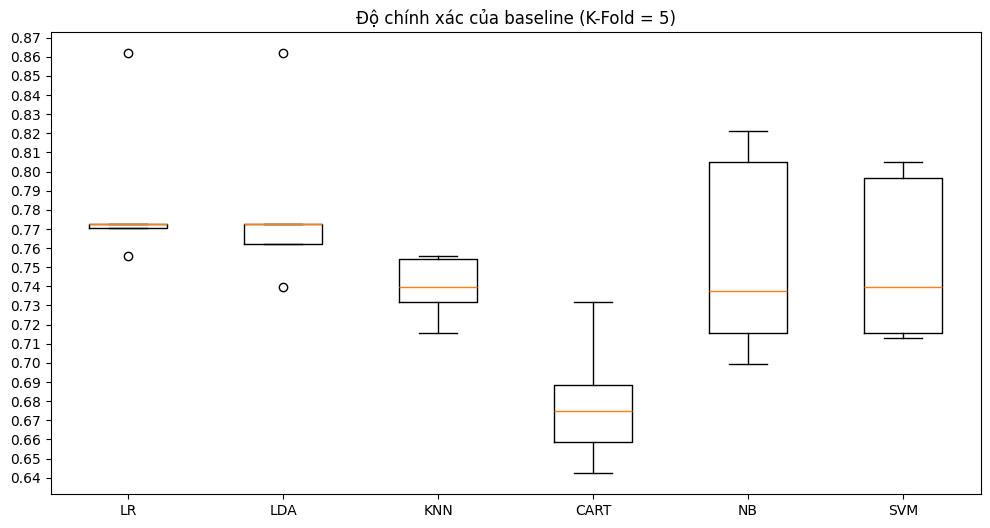

In [59]:
# In biểu đồ box-plot trên độ chính xác với k-fold
plt.figure(figsize=(12,6))
plt.boxplot(baseline_results.values())
plt.gca().set_xticklabels(baseline_results.keys())
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.01))
plt.title(f'Độ chính xác của baseline (K-Fold = {params["k_fold"]})')
plt.show()

### 6.2. Tinh chỉnh mô hình (Tuning Models)

In [60]:
tunning_results = {
    "best_clf"   : {},
    "best_score" : {},
}

tunning_models  = {}
tunning_params  = {}

# khởi tạo các tham số mặc định
tunning_models['KNN']  = KNeighborsClassifier()
tunning_params['KNN']  = {
    'n_neighbors': [2, 4, 6, 8, 10],
}

tunning_models['SVM']  = SVC(decision_function_shape = 'ovr',
                             class_weight = 'balanced',
                             probability  = True,
                             random_state = params["random_state"])
tunning_params['SVM']  = {
    'kernel': ['linear', 'rbf'], # 'sigmoid', 'poly'
    'C': [1, 10, 100,200], # 50, 70
    'gamma': [1e-3, 1e-2], # 1e-4
}

for model_name in tunning_models:
    model_clf = tunning_models[model_name]

    print(f'Model [{model_name}]:')

    kfold = KFold(n_splits=params["k_fold"], shuffle=True, random_state=params["random_state"])

    grid_clf = GridSearchCV(estimator=model_clf,
                            param_grid=tunning_params[model_name],
                            cv = kfold, scoring="accuracy")
    grid_result = grid_clf.fit(X_train, y_train)

    # store best model
    tunning_results["best_clf"][model_name] = grid_clf.best_estimator_

    # get search results
    tunning_results["best_score"][model_name] = grid_result.best_score_


    # information
    print(f'+ Best score: {grid_result.best_score_}')
    print(f'+ Best turnning params: {grid_result.best_params_}')
    print(f'+ Best full params: {grid_clf.best_estimator_.get_params()}')
    print()

    pass

Model [KNN]:
+ Best score: 0.765400506464081
+ Best turnning params: {'n_neighbors': 10}
+ Best full params: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 10, 'p': 2, 'weights': 'uniform'}

Model [SVM]:
+ Best score: 0.7606024256963881
+ Best turnning params: {'C': 200, 'gamma': 0.001, 'kernel': 'rbf'}
+ Best full params: {'C': 200, 'break_ties': False, 'cache_size': 200, 'class_weight': 'balanced', 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 0.001, 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}



## 7. Kiểm nghiệm kết quả trên Test (Finalize Model)

### Load Tập test

In [61]:
X_test = pd.read_csv(params["data_path_X_test"])
y_test = pd.read_csv(params["data_path_Y_test"])

## Đánh giá Baseline

Baseline [LR]
+ acc = 0.708


array([[82, 18],
       [27, 27]], dtype=int64)

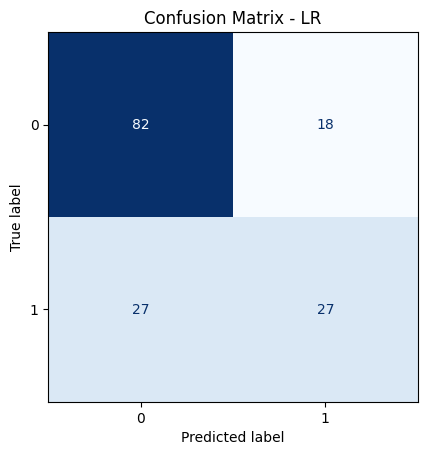

Baseline [LDA]
+ acc = 0.701


array([[82, 18],
       [28, 26]], dtype=int64)

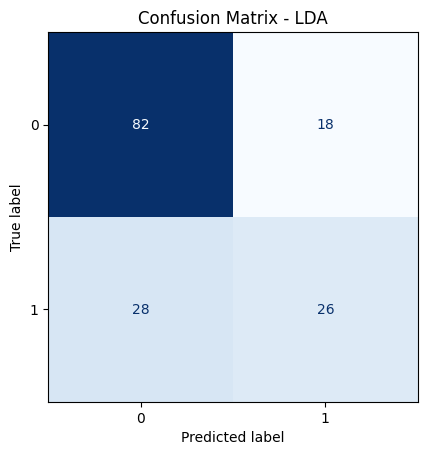

Baseline [KNN]
+ acc = 0.753


array([[83, 17],
       [21, 33]], dtype=int64)

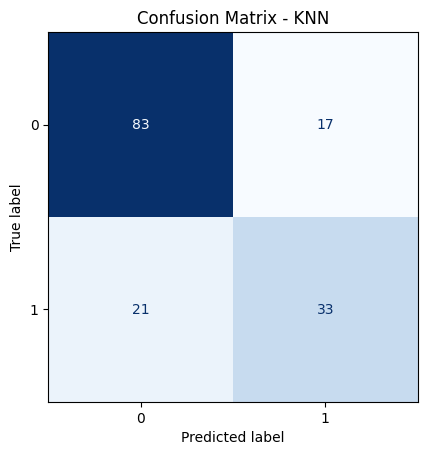

Baseline [CART]
+ acc = 0.682


array([[79, 21],
       [28, 26]], dtype=int64)

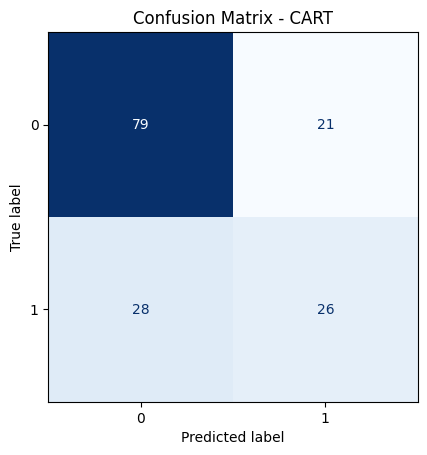

Baseline [NB]
+ acc = 0.701


array([[74, 26],
       [20, 34]], dtype=int64)

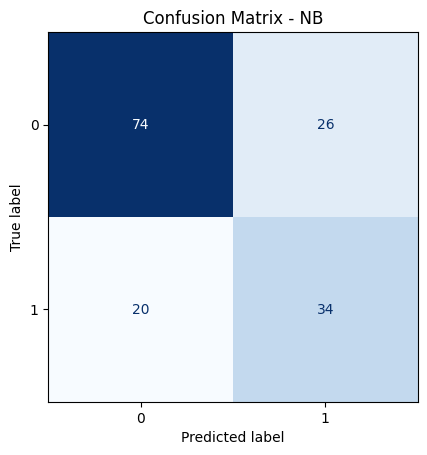

Baseline [SVM]
+ acc = 0.740


array([[84, 16],
       [24, 30]], dtype=int64)

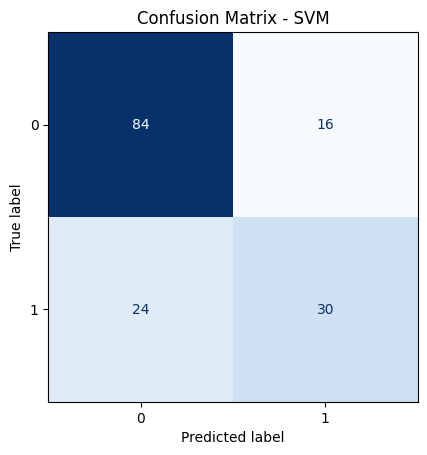

In [62]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score

test_models  = {}
test_scores  = {}

# Kiểm tra kết quả trên tập test (baseline)
for model_name in baseline_models:
    model_clf = baseline_models[model_name]
    y_pred_test = model_clf.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_test)

    print(f'Baseline [{model_name}]')
    print(f'+ acc = {test_acc:.3f}')

    cm = confusion_matrix(y_test, y_pred_test)
    display.display(cm)

    # ✅ Chuyển y_test sang 1 chiều
    y_test_flat = np.ravel(y_test)

    # ✅ Lấy nhãn duy nhất
    labels = np.unique(np.concatenate((y_test_flat, y_pred_test)))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues', colorbar=False)

    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()


## 8. Lưu kết quả thí nghiệm

In [66]:
save_dir = params["save_dir"]
!jupyter nbconvert "D:/Kaggle ML/Team_SGU_25_ML_Fundamental/dntai_log_exps/PimaIndia/models/model1.ipynb" \
    --to html \
    --output-dir "{save_dir}" \
    --output model1


[NbConvertApp] Converting notebook D:/Kaggle ML/Team_SGU_25_ML_Fundamental/dntai_log_exps/PimaIndia/models/model1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 484702 bytes to ..\exps\result1_Pima_02_standard\model1.html
